In [1]:
# Run once only
#!pip install yfinance pandas numpy

# Income Objective Portfolio Construction (Bursa Malaysia)

Phase 1:
- Data collection
- Data cleaning
- Return computation
- Volatility classification (Stage 1 & Stage 2)

Benchmark: FTSE Bursa Malaysia KLCI

In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import os

# Fixed seed for reproducibility.
# The final stock selection is rules-based, but setting a seed supports reproducibility discipline.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ANNUALIZATION = 252
RANDOM_SEED = 2025
OBJECTIVE = "income"
BENCHMARK_COL = "fbmklci"

ASSET_CAP = 0.25
VOL_CAP = 0.10
DIV_YIELD = None

In [46]:
# =========================================================
# 2. RISK-FREE RATE CALCULATION
# =========================================================
# The risk-free rate is estimated using Malaysia 3-Year Government Bond Yield data.
# The 3-year MGS proxy is selected because the equity dataset also covers
# approximately three years, so it matches the investment horizon of the analysis.
#
# We calculate the average monthly yield over the same period as the stock dataset
# to avoid using a single-date assumption.

import pandas as pd
import os

MGS_CSV = r"C:\Users\user\Documents\Y2S2\RBA\GroupRBA\data\3Year_MGS\Malaysia 3-Year Bond Yield Historical Data.csv"

# Stock analysis period
START_DATE = "2023-05-22"
END_DATE = "2026-05-20"

# Load MGS yield data
mgs = pd.read_csv(MGS_CSV)

# Standardise column names
mgs.columns = mgs.columns.str.strip()

# Convert date and yield columns
mgs["Date"] = pd.to_datetime(mgs["Date"], errors="coerce")
mgs["Yield"] = pd.to_numeric(mgs["Price"], errors="coerce")

# Remove invalid rows
mgs = mgs.dropna(subset=["Date", "Yield"])

# Filter to match stock sample period
mgs_period = mgs[
    (mgs["Date"] >= START_DATE) &
    (mgs["Date"] <= END_DATE)
].copy()

# Sort chronologically
mgs_period = mgs_period.sort_values("Date")

# Convert daily yield observations into monthly observations.
# We use the last available trading yield for each month.
mgs_period["Month"] = mgs_period["Date"].dt.to_period("M")

mgs_monthly = (
    mgs_period
    .sort_values("Date")
    .groupby("Month", as_index=False)
    .tail(1)
    .copy()
)

# Calculate average annual risk-free rate
RF_ANNUAL = mgs_monthly["Yield"].mean() / 100
RF_DAILY = RF_ANNUAL / ANNUALIZATION

print("Risk-Free Rate Source: Malaysia 3-Year Government Bond Yield")
print(f"Risk-free rate period: {mgs_period['Date'].min().date()} to {mgs_period['Date'].max().date()}")
print(f"Daily observations used before monthly conversion: {len(mgs_period)}")
print(f"Monthly observations used: {len(mgs_monthly)}")
print(f"Average annual risk-free rate: {RF_ANNUAL:.4%}")
print(f"Daily risk-free rate: {RF_DAILY:.6%}")

display(mgs_monthly[["Month", "Date", "Yield"]].reset_index(drop=True))

Risk-Free Rate Source: Malaysia 3-Year Government Bond Yield
Risk-free rate period: 2023-05-22 to 2026-05-20
Daily observations used before monthly conversion: 819
Monthly observations used: 37
Average annual risk-free rate: 3.3333%
Daily risk-free rate: 0.013227%


,Month,Date,Yield
0,2023-05,2023-05-31,3.409
1,2023-06,2023-06-30,3.505
2,2023-07,2023-07-31,3.497
3,2023-08,2023-08-31,3.491
4,2023-09,2023-09-29,3.570
5,2023-10,2023-10-31,3.665
6,2023-11,2023-11-30,3.508
7,2023-12,2023-12-29,3.470
8,2024-01,2024-01-31,3.397
9,2024-02,2024-02-29,3.466


In [47]:
# =========================================================
# SAVE RISK-FREE RATE OUTPUT
# =========================================================

os.makedirs("output", exist_ok=True)

mgs_monthly[["Month", "Date", "Yield"]].to_csv(
    "output/risk_free_rate_3year_mgs_monthly.csv",
    index=False
)

pd.DataFrame({
    "Risk-Free Proxy": ["Malaysia 3-Year Government Bond Yield"],
    "Start Date": [START_DATE],
    "End Date": [END_DATE],
    "Average Annual Risk-Free Rate": [RF_ANNUAL],
    "Daily Risk-Free Rate": [RF_DAILY],
    "Monthly Observations": [len(mgs_monthly)]
}).to_csv(
    "output/risk_free_rate_summary.csv",
    index=False
)

print("✅ Risk-free rate files saved successfully.")

✅ Risk-free rate files saved successfully.


In [ ]:
RISK_FREE_RATE_ANNUAL = RF_ANNUAL
RISK_FREE_RATE_DAILY = RF_DAILY

# Phase 1
## 1. Candidate Pool Selection

A diversified candidate pool of 40 Bursa Malaysia stocks is used. The pool includes a mix of sectors such as banking, utilities, healthcare, technology, plantation, industrials, energy, retail, and telecommunications.

This avoids manually pre-selecting only stable or risky stocks. Instead, volatility classification is allowed to emerge from the computed return and volatility statistics.

In [3]:
stocks = [
    # Banks and financials
    "1155.KL", "1295.KL", "1023.KL", "5819.KL", "1066.KL",
    "1082.KL", "2488.KL", "1015.KL", "5185.KL", "1818.KL",

    # Utilities, telecom, infrastructure, energy
    "5347.KL", "6033.KL", "6742.KL", "6947.KL", "6888.KL",
    "7277.KL", "4677.KL", "4863.KL", "5210.KL", "5258.KL",

    # Healthcare and glove-related stocks
    "5225.KL", "5878.KL", "5168.KL", "7113.KL", "7106.KL",
    "7081.KL", "7148.KL",

    # Consumer, retail, defensive, plantation
    "4707.KL", "3816.KL", "6012.KL", "2445.KL", "1961.KL",
    "4065.KL", "7084.KL", "5296.KL", "5681.KL", "1562.KL",
    "3689.KL", "3026.KL",

    # Property, construction, industrials
    "5211.KL", "5288.KL", "5289.KL", "1619.KL", "4197.KL",
    "3182.KL", "4715.KL", "5398.KL", "3336.KL", "5099.KL",

    # Technology and higher-volatility candidates
    "0138.KL", "0166.KL", "0097.KL", "0128.KL", "5216.KL",
    "7203.KL", "5292.KL", "5306.KL", "0272.KL",

    # Additional Bursa candidates for wider screening
    "5285.KL", "5296.KL", "5020.KL", "5008.KL", "5176.KL",
    "5236.KL", "5246.KL", "5250.KL", "5273.KL", "5297.KL",
    "5302.KL", "5309.KL", "5310.KL", "5318.KL", "5326.KL",
    "7047.KL", "7084.KL", "7132.KL", "7153.KL",
    "7191.KL", "7214.KL", "7223.KL", "7233.KL"
]

# Remove accidental duplicates while preserving order
stocks = list(dict.fromkeys(stocks))

benchmark = "^KLSE"

print(f"Candidate pool size after removing duplicates: {len(stocks)} stocks")

Candidate pool size after removing duplicates: 79 stocks


## 2. Data Collection

3 years of daily adjusted closing prices are downloaded using Yahoo Finance.

In [4]:
print("Downloading 3 years of daily adjusted closing prices...")

raw_data = yf.download(
    stocks + [benchmark],
    period="3y",
    auto_adjust=True,
    progress=True
)

prices = raw_data["Close"].copy()
prices = prices.sort_index()

# Remove columns that are completely missing due to invalid or unavailable tickers
prices = prices.dropna(axis=1, how="all")

if benchmark not in prices.columns:
    raise ValueError("Benchmark ^KLSE was not downloaded. Check Yahoo Finance availability.")

stock_prices = prices.drop(columns=[benchmark]).copy()
benchmark_prices = prices[benchmark].copy()
benchmark_prices.name = "fbmklci"

print("Download completed.")
print(f"Available stock price shape: {stock_prices.shape}")
print(f"Benchmark observations: {benchmark_prices.shape[0]}")
print(f"Successfully downloaded stocks: {len(stock_prices.columns)}")

[*********************100%***********************]  80 of 80 completed


Download completed.
Available stock price shape: (740, 79)
Benchmark observations: 740
Successfully downloaded stocks: 79


## 3. Data Cleaning and Alignment

Stocks with excessive missing values are removed using a 90% data availability threshold. This keeps the dataset reliable while avoiding unnecessary loss of diversification.

After cleaning, stock prices and FBMKLCI are aligned on the same trading dates.

In [5]:
minimum_required_observations = int(len(stock_prices) * 0.90)

stock_prices_clean = stock_prices.dropna(
    axis=1,
    thresh=minimum_required_observations
).copy()

# Combine stocks with benchmark and align dates
cleaned_prices = pd.concat([stock_prices_clean, benchmark_prices], axis=1)
cleaned_prices = cleaned_prices.dropna(subset=["fbmklci"])

# Drop any remaining rows with missing stock prices
# This ensures all returns are computed on fully aligned dates
cleaned_prices = cleaned_prices.dropna(how="any")

stock_prices_clean = cleaned_prices.drop(columns=["fbmklci"])
benchmark_prices_clean = cleaned_prices["fbmklci"]

print(f"Remaining stocks after cleaning: {len(stock_prices_clean.columns)}")
print(stock_prices_clean.columns.tolist())
print(f"\nCleaned price dataset shape including benchmark: {cleaned_prices.shape}")
print(f"Date range: {cleaned_prices.index.min().date()} to {cleaned_prices.index.max().date()}")

Remaining stocks after cleaning: 78
['0097.KL', '0128.KL', '0138.KL', '0166.KL', '0272.KL', '1015.KL', '1023.KL', '1066.KL', '1082.KL', '1155.KL', '1295.KL', '1562.KL', '1619.KL', '1818.KL', '1961.KL', '2445.KL', '2488.KL', '3026.KL', '3182.KL', '3336.KL', '3689.KL', '3816.KL', '4065.KL', '4197.KL', '4677.KL', '4707.KL', '4715.KL', '4863.KL', '5008.KL', '5020.KL', '5099.KL', '5168.KL', '5176.KL', '5185.KL', '5210.KL', '5211.KL', '5216.KL', '5225.KL', '5236.KL', '5246.KL', '5250.KL', '5258.KL', '5273.KL', '5285.KL', '5288.KL', '5289.KL', '5292.KL', '5296.KL', '5297.KL', '5302.KL', '5306.KL', '5309.KL', '5310.KL', '5318.KL', '5347.KL', '5398.KL', '5681.KL', '5819.KL', '5878.KL', '6012.KL', '6033.KL', '6742.KL', '6888.KL', '6947.KL', '7047.KL', '7081.KL', '7084.KL', '7106.KL', '7113.KL', '7132.KL', '7148.KL', '7153.KL', '7191.KL', '7203.KL', '7214.KL', '7223.KL', '7233.KL', '7277.KL']

Cleaned price dataset shape including benchmark: (737, 79)
Date range: 2023-05-22 to 2026-05-20


## 4. Log Return Calculation

Log returns are computed instead of simple percentage returns because the marking rubric expects log returns.

rₜ = ln(Pₜ / Pₜ₋₁)

Where:
- rₜ = daily log return at time t
- Pₜ = closing price at time t
- Pₜ₋₁ = closing price on the previous trading day
- ln = natural logarithm

Log returns are suitable for statistical analysis because they are time-additive and commonly used in financial modelling.

In [6]:
returns = np.log(stock_prices_clean / stock_prices_clean.shift(1)).dropna(how="any")
benchmark_returns = np.log(benchmark_prices_clean / benchmark_prices_clean.shift(1)).dropna()

# Align stocks and benchmark on common dates
common_dates = returns.index.intersection(benchmark_returns.index)
returns = returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]

returns_with_benchmark = pd.concat(
    [returns, benchmark_returns.rename("fbmklci")],
    axis=1
)

print(f"Stock log return dataset shape: {returns.shape}")
print(f"Benchmark log return observations: {benchmark_returns.shape[0]}")
print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")

Stock log return dataset shape: (736, 78)
Benchmark log return observations: 736
Date range: 2023-05-23 to 2026-05-20


## 5. Daily Statistics

For each stock, the following statistics are computed:

- Mean Return: average daily log return
- Volatility: standard deviation of daily log returns
- Annual Return: daily mean return × 252
- Annual Risk: daily volatility × √252

These statistics support Stage 1 and Stage 2 volatility classification.

In [7]:
TRADING_DAYS = 252

mean_returns = returns.mean()
volatility = returns.std()

stats_full = pd.DataFrame({
    "Mean Return": mean_returns,
    "Volatility": volatility,
    "Annual Return": mean_returns * TRADING_DAYS,
    "Annual Risk": volatility * np.sqrt(TRADING_DAYS)
})

stats_full = stats_full[stats_full["Volatility"] > 0].copy()
stats_full["Return/Risk Ratio"] = stats_full["Mean Return"] / stats_full["Volatility"]

display(stats_full.head())
print(f"Total valid stocks for filtering: {len(stats_full)}")

,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
0097.KL,-0.000308,0.035525,-0.077709,0.563943,-0.008680
0128.KL,0.000686,0.021306,0.172977,0.338215,0.032218
0138.KL,0.000173,0.024909,0.043633,0.395411,0.006951
0166.KL,-0.000121,0.027473,-0.030494,0.436123,-0.004405
0272.KL,-0.001680,0.044321,-0.423276,0.703580,-0.037897


Total valid stocks for filtering: 78


## 6. Stage 1: Low-Volatility Stock Selection

The assignment states that Stage 1 should contain 10 low-volatility stocks where:

(daily r̄p > daily σp) 

If fewer than 10 stocks satisfy the rule, a stabiliser is applied:
- keep only stocks with positive mean returns, and
- select the 10 stocks with the lowest volatility.

This stabiliser is consistent with the income objective because income portfolios prioritise positive return and stable risk.

In [8]:
stats_positive = stats_full[stats_full["Mean Return"] > 0].copy()

print(f"Stocks with positive mean returns: {len(stats_positive)}")
print(f"Stocks excluded due to negative mean returns: {len(stats_full) - len(stats_positive)}")

low_vol_condition = stats_positive[
    stats_positive["Mean Return"] > stats_positive["Volatility"]
].copy()

print(f"Stocks satisfying strict Stage 1 rule: {len(low_vol_condition)}")

if len(low_vol_condition) >= 10:
    low_vol = low_vol_condition.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()

    low_vol_method = "Strict assignment rule: Mean Return > Volatility"

else:
    print("Fewer than 10 stocks met the strict Stage 1 rule.")
    print("Applying stabiliser: positive-return stocks with lowest volatility.")

    low_vol = stats_positive.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()

    low_vol_method = "Stabiliser: positive-return stocks with lowest volatility"

low_vol["Selection Method"] = low_vol_method

print("\nStage 1 Low-Volatility Stocks:")
display(low_vol[["Mean Return", "Volatility", "Annual Return", "Annual Risk", "Return/Risk Ratio"]])

Stocks with positive mean returns: 45
Stocks excluded due to negative mean returns: 33
Stocks satisfying strict Stage 1 rule: 0
Fewer than 10 stocks met the strict Stage 1 rule.
Applying stabiliser: positive-return stocks with lowest volatility.

Stage 1 Low-Volatility Stocks:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
1155.KL,0.000591,0.007732,0.148877,0.122746,0.076404
1066.KL,0.000834,0.008860,0.210263,0.140641,0.094178
5819.KL,0.000268,0.009336,0.067634,0.148207,0.028747
6033.KL,0.000185,0.009637,0.046519,0.152989,0.019154
5225.KL,0.000639,0.009669,0.160934,0.153486,0.066051
1082.KL,0.000187,0.009892,0.047066,0.157026,0.018881
1818.KL,0.000588,0.010275,0.148142,0.163104,0.057215
1295.KL,0.000447,0.010407,0.112620,0.165211,0.042942
5347.KL,0.000716,0.010693,0.180465,0.169740,0.066974
3816.KL,0.000338,0.010782,0.085127,0.171159,0.031330


## 7. Stage 2: High-Volatility Stock Selection

The assignment states that Stage 2 should add 5 high-volatility stocks where:

(daily σp > 3.0  of daily r̄p ) 

The full stock universe is used for this rule because Stage 2 is designed to test the effect of adding riskier stocks, including stocks with weak or negative recent performance.

In [9]:
high_vol_candidates = stats_full[
    (stats_full["Volatility"] > 3 * stats_full["Mean Return"]) &
    (stats_full["Mean Return"] > 0)
].copy()

print(f"Positive-return stocks satisfying Stage 2 high-volatility rule: {len(high_vol_candidates)}")

if len(high_vol_candidates) >= 5:
    high_vol = high_vol_candidates.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()

    high_vol_method = "Assignment high-volatility rule with positive-return stabiliser"

else:
    print("Fewer than 5 positive-return stocks met the high-volatility rule.")
    print("Applying stabiliser: selecting highest-volatility positive-return stocks.")

    high_vol = stats_positive.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()

    high_vol_method = "Stabiliser: highest-volatility positive-return stocks"

high_vol["Meets High-Vol Rule"] = high_vol["Volatility"] > 3 * high_vol["Mean Return"]
high_vol["Selection Method"] = high_vol_method

print("\nStage 2 High-Volatility Additions:")
display(high_vol[["Mean Return", "Volatility", "Annual Return", "Annual Risk", "Return/Risk Ratio", "Meets High-Vol Rule"]])

Positive-return stocks satisfying Stage 2 high-volatility rule: 45

Stage 2 High-Volatility Additions:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio,Meets High-Vol Rule
5297.KL,0.000164,0.037427,0.041358,0.594130,0.004385,True
5292.KL,0.000801,0.029844,0.201762,0.473758,0.026828,True
4677.KL,0.001436,0.029232,0.361928,0.464046,0.049132,True
6742.KL,0.001793,0.026805,0.451786,0.425515,0.066883,True
5288.KL,0.001666,0.025403,0.419868,0.403257,0.065589,True


## 8. Final Selected Universes

- Stage 1 contains 10 low-volatility stocks.

- Stage 2 contains the Stage 1 stocks plus 5 high-volatility additions.

These two universes will be used in the next phase for annual return, annual risk, beta, Sharpe ratio, and portfolio optimisation.

In [10]:
stage1_stocks = list(low_vol.index)
stage2_additions = list(high_vol.index)
stage2_stocks = stage1_stocks + stage2_additions

selected_stocks = stage2_stocks

print("Stage 1 Low-Volatility Universe:")
print(stage1_stocks)

print("\nStage 2 High-Volatility Additions:")
print(stage2_additions)

print("\nStage 2 Full Universe:")
print(stage2_stocks)

print(f"\nStage 1 size: {len(stage1_stocks)}")
print(f"Stage 2 size: {len(stage2_stocks)}")

Stage 1 Low-Volatility Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']

Stage 2 High-Volatility Additions:
['5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 2 Full Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 1 size: 10
Stage 2 size: 15


## 9. Export Phase 1 Outputs

The following files are saved for reproducibility and for use in later phases:

- Candidate pool
- Cleaned price dataset
- Log return dataset
- Benchmark log returns
- Stock statistics
- Stage 1 selected stocks
- Stage 2 selected stocks
- Stage 1 and Stage 2 return datasets

In [11]:
OVERWRITE_OUTPUT = True

if OVERWRITE_OUTPUT:
    os.makedirs("output", exist_ok=True)

    pd.Series(stocks, name="Candidate Pool").to_csv(
        "output/candidate_pool.csv",
        index=False
    )

    cleaned_prices.to_csv("output/cleaned_prices_with_fbmklci.csv")

    returns.to_csv("output/log_returns.csv")
    benchmark_returns.rename("fbmklci").to_csv("output/fbmklci_log_returns.csv")
    returns_with_benchmark.to_csv("output/log_returns_with_fbmklci.csv")

    stats_full.to_csv("output/stock_statistics_full.csv")
    low_vol.to_csv("output/stage1_low_vol_stocks.csv")
    high_vol.to_csv("output/stage2_high_vol_additions.csv")

    pd.Series(stage1_stocks, name="Stage 1 Stocks").to_csv(
        "output/stage1_stocks.csv",
        index=False
    )

    pd.Series(stage2_additions, name="Stage 2 Additions").to_csv(
        "output/stage2_additions.csv",
        index=False
    )

    pd.Series(stage2_stocks, name="Stage 2 Full Universe").to_csv(
        "output/stage2_stocks.csv",
        index=False
    )

    returns_stage1 = returns[stage1_stocks].copy()
    returns_stage2 = returns[stage2_stocks].copy()

    returns_stage1.to_csv("output/log_returns_stage1.csv")
    returns_stage2.to_csv("output/log_returns_stage2.csv")

    print("Phase 1 outputs saved successfully.")
    print("Saved files in /output folder.")

else:
    print("Output saving skipped.")

Phase 1 outputs saved successfully.
Saved files in /output folder.


## 10. Raw Individual Stock Data Export

Run only once for dataset generation.

In [12]:
SAVE_RAW_DATA = False

if SAVE_RAW_DATA:
    os.makedirs("raw_data", exist_ok=True)

    for ticker in stock_prices_clean.columns:
        individual_df = stock_prices_clean[[ticker]].dropna()
        individual_df.to_csv(f"raw_data/{ticker}.csv")

    benchmark_prices_clean.rename("fbmklci").to_csv("raw_data/fbmklci.csv")

    print("✅ Raw individual stock files saved in /raw_data folder.")

else:
    print("Raw data export skipped.")

Raw data export skipped.


# PHASE 2
## 1. LOAD PHASE 1 OUTPUTS

In [13]:
returns_stage1 = pd.read_csv("output/log_returns_stage1.csv", index_col=0, parse_dates=True)
returns_stage2 = pd.read_csv("output/log_returns_stage2.csv", index_col=0, parse_dates=True)
benchmark_returns = pd.read_csv("output/fbmklci_log_returns.csv", index_col=0, parse_dates=True).squeeze("columns")

stats_full = pd.read_csv("output/stock_statistics_full.csv", index_col=0)
stage1_stocks = pd.read_csv("output/stage1_stocks.csv")["Stage 1 Stocks"].dropna().astype(str).tolist()
stage2_additions = pd.read_csv("output/stage2_additions.csv")["Stage 2 Additions"].dropna().astype(str).tolist()
stage2_stocks = pd.read_csv("output/stage2_stocks.csv")["Stage 2 Full Universe"].dropna().astype(str).tolist()

print("Stage 1 stocks:", stage1_stocks)
print("Stage 2 additions:", stage2_additions)
print("Stage 2 full universe:", stage2_stocks)

print("\nStage 1 return shape:", returns_stage1.shape)
print("Stage 2 return shape:", returns_stage2.shape)
print("Benchmark return observations:", len(benchmark_returns))

Stage 1 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']
Stage 2 additions: ['5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']
Stage 2 full universe: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 1 return shape: (736, 10)
Stage 2 return shape: (736, 15)
Benchmark return observations: 736


## 1. Align Stock Returns with FBMKLCI

Before calculating beta, stock returns and benchmark returns must be aligned on the same trading dates.

This avoids calculation errors caused by missing or mismatched dates.

In [14]:
common_dates = returns_stage2.index.intersection(benchmark_returns.index)

returns_stage1 = returns_stage1.loc[common_dates.intersection(returns_stage1.index)]
returns_stage2 = returns_stage2.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]

print("Aligned Stage 1 shape:", returns_stage1.shape)
print("Aligned Stage 2 shape:", returns_stage2.shape)
print("Aligned benchmark observations:", len(benchmark_returns))

Aligned Stage 1 shape: (736, 10)
Aligned Stage 2 shape: (736, 15)
Aligned benchmark observations: 736


## 2. Beta Calculation

Beta measures how sensitive each stock is to the FBMKLCI benchmark.

Formula:

βᵢ = Cov(rᵢ, rₘ) / Var(rₘ)

Where:
- βᵢ = beta of stock i
- rᵢ = return of stock i
- rₘ = return of the market benchmark, FBMKLCI
- Cov(rᵢ, rₘ) = covariance between stock i return and market return
- Var(rₘ) = variance of the market return

Interpretation:
- Beta < 1: less sensitive than the market
- Beta = 1: moves similarly to the market
- Beta > 1: more sensitive than the market

In [15]:
def calculate_beta(stock_returns, market_returns):
    """
    Calculate beta of one stock against the market benchmark.
    
    Beta = Cov(stock return, market return) / Var(market return)
    """
    aligned = pd.concat([stock_returns, market_returns], axis=1).dropna()
    aligned.columns = ["stock", "market"]
    
    covariance = aligned["stock"].cov(aligned["market"])
    market_variance = aligned["market"].var()
    
    return covariance / market_variance


beta_values = {}

for ticker in stage2_stocks:
    beta_values[ticker] = calculate_beta(
        returns_stage2[ticker],
        benchmark_returns
    )

beta = pd.Series(beta_values, name="Beta vs FBMKLCI")

print("Beta vs FBMKLCI:")
display(beta.round(4))

Beta vs FBMKLCI:


1155.KL    0.8262
1066.KL    0.7872
5819.KL    0.7904
6033.KL    0.5397
5225.KL    0.5683
1082.KL    0.7040
1818.KL    0.6875
1295.KL    1.0789
5347.KL    0.9534
3816.KL    0.6436
5297.KL    1.0154
5292.KL    1.6727
4677.KL    1.8263
6742.KL    1.6732
5288.KL    1.8574
Name: Beta vs FBMKLCI, dtype: float64

## 3. Sharpe Ratio Calculation

Sharpe ratio measures risk-adjusted return.

Formula:

Sharpe = (Rₚ - Rf) / σₚ

Where:
- Sharpe = Sharpe ratio of the portfolio
- Rₚ = portfolio return
- Rf = risk-free rate
- σₚ = portfolio risk or standard deviation of portfolio returns

An annual risk-free rate of 3% is assumed as a simple proxy for Malaysia’s low-risk return environment. The same risk-free rate is applied consistently across all stocks and portfolios.

In [ ]:
RISK_FREE_RATE_ANNUAL = RF_ANNUAL
RISK_FREE_RATE_DAILY = RF_DAILY

# Use selected Stage 2 universe because it contains all 15 stocks
individual_metrics = stats_full.loc[stage2_stocks].copy()

# Add beta
individual_metrics["Beta vs FBMKLCI"] = beta

# Calculate Sharpe ratio using annualised values
individual_metrics["Sharpe Ratio"] = (
    (individual_metrics["Annual Return"] - RISK_FREE_RATE_ANNUAL) /
    individual_metrics["Annual Risk"]
)

# Add stage label
stage_labels = []

for ticker in individual_metrics.index:
    if ticker in stage1_stocks:
        stage_labels.append("Stage 1 Low Volatility")
    elif ticker in stage2_additions:
        stage_labels.append("Stage 2 High Volatility Addition")
    else:
        stage_labels.append("Unclassified")

individual_metrics["Stage"] = stage_labels

# Reorder columns for report readability
individual_metrics = individual_metrics[
    [
        "Stage",
        "Mean Return",
        "Volatility",
        "Annual Return",
        "Annual Risk",
        "Beta vs FBMKLCI",
        "Sharpe Ratio",
        "Return/Risk Ratio"
    ]
]

print("Individual Stock Metrics:")
display(individual_metrics.round(4))

Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0077,0.1489,0.1227,0.8262,0.9685,0.0764
1066.KL,Stage 1 Low Volatility,0.0008,0.0089,0.2103,0.1406,0.7872,1.2817,0.0942
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0676,0.1482,0.7904,0.2539,0.0287
6033.KL,Stage 1 Low Volatility,0.0002,0.0096,0.0465,0.1530,0.5397,0.1080,0.0192
5225.KL,Stage 1 Low Volatility,0.0006,0.0097,0.1609,0.1535,0.5683,0.8531,0.0661
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0471,0.1570,0.7040,0.1087,0.0189
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1481,0.1631,0.6875,0.7243,0.0572
1295.KL,Stage 1 Low Volatility,0.0004,0.0104,0.1126,0.1652,1.0789,0.5001,0.0429
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1805,0.1697,0.9534,0.8864,0.0670
3816.KL,Stage 1 Low Volatility,0.0003,0.0108,0.0851,0.1712,0.6436,0.3221,0.0313


## 4. Stage 1 and Stage 2 Individual Stock Tables

The individual stock metrics are separated into Stage 1 and Stage 2 tables for clearer reporting.

In [17]:
stage1_individual_metrics = individual_metrics.loc[stage1_stocks].copy()
stage2_addition_metrics = individual_metrics.loc[stage2_additions].copy()

print("Stage 1 Individual Stock Metrics:")
display(stage1_individual_metrics.round(4))

print("Stage 2 High-Volatility Addition Metrics:")
display(stage2_addition_metrics.round(4))

Stage 1 Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0077,0.1489,0.1227,0.8262,0.9685,0.0764
1066.KL,Stage 1 Low Volatility,0.0008,0.0089,0.2103,0.1406,0.7872,1.2817,0.0942
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0676,0.1482,0.7904,0.2539,0.0287
6033.KL,Stage 1 Low Volatility,0.0002,0.0096,0.0465,0.1530,0.5397,0.1080,0.0192
5225.KL,Stage 1 Low Volatility,0.0006,0.0097,0.1609,0.1535,0.5683,0.8531,0.0661
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0471,0.1570,0.7040,0.1087,0.0189
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1481,0.1631,0.6875,0.7243,0.0572
1295.KL,Stage 1 Low Volatility,0.0004,0.0104,0.1126,0.1652,1.0789,0.5001,0.0429
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1805,0.1697,0.9534,0.8864,0.0670
3816.KL,Stage 1 Low Volatility,0.0003,0.0108,0.0851,0.1712,0.6436,0.3221,0.0313


Stage 2 High-Volatility Addition Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
5297.KL,Stage 2 High Volatility Addition,0.0002,0.0374,0.0414,0.5941,1.0154,0.0191,0.0044
5292.KL,Stage 2 High Volatility Addition,0.0008,0.0298,0.2018,0.4738,1.6727,0.3626,0.0268
4677.KL,Stage 2 High Volatility Addition,0.0014,0.0292,0.3619,0.4640,1.8263,0.7153,0.0491
6742.KL,Stage 2 High Volatility Addition,0.0018,0.0268,0.4518,0.4255,1.6732,0.9912,0.0669
5288.KL,Stage 2 High Volatility Addition,0.0017,0.0254,0.4199,0.4033,1.8574,0.9668,0.0656


## 5. Correlation Analysis

Correlation shows how strongly stocks move together.

This is important because diversification benefits are weaker when stocks are highly correlated. A high correlation between two stocks means they tend to move in the same direction, reducing the benefit of holding both.

In [18]:
correlation_stage1 = returns_stage1.corr()
correlation_stage2 = returns_stage2.corr()

print("Stage 1 Correlation Matrix:")
display(correlation_stage1.round(3))

print("Stage 2 Correlation Matrix:")
display(correlation_stage2.round(3))

Stage 1 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL
1155.KL,1.000,0.541,0.488,0.227,0.229,0.381,0.364,0.505,0.301,0.183
1066.KL,0.541,1.000,0.534,0.208,0.229,0.357,0.277,0.455,0.257,0.117
5819.KL,0.488,0.534,1.000,0.250,0.225,0.479,0.319,0.440,0.239,0.096
6033.KL,0.227,0.208,0.250,1.000,0.174,0.156,0.088,0.236,0.122,0.215
5225.KL,0.229,0.229,0.225,0.174,1.000,0.138,0.167,0.239,0.204,0.042
1082.KL,0.381,0.357,0.479,0.156,0.138,1.000,0.301,0.331,0.210,0.158
1818.KL,0.364,0.277,0.319,0.088,0.167,0.301,1.000,0.255,0.280,0.165
1295.KL,0.505,0.455,0.440,0.236,0.239,0.331,0.255,1.000,0.297,0.152
5347.KL,0.301,0.257,0.239,0.122,0.204,0.210,0.280,0.297,1.000,0.130
3816.KL,0.183,0.117,0.096,0.215,0.042,0.158,0.165,0.152,0.130,1.000


Stage 2 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL,5297.KL,5292.KL,4677.KL,6742.KL,5288.KL
1155.KL,1.000,0.541,0.488,0.227,0.229,0.381,0.364,0.505,0.301,0.183,0.133,0.206,0.152,0.137,0.285
1066.KL,0.541,1.000,0.534,0.208,0.229,0.357,0.277,0.455,0.257,0.117,0.107,0.177,0.115,0.138,0.225
5819.KL,0.488,0.534,1.000,0.250,0.225,0.479,0.319,0.440,0.239,0.096,0.092,0.146,0.124,0.101,0.196
6033.KL,0.227,0.208,0.250,1.000,0.174,0.156,0.088,0.236,0.122,0.215,0.119,0.144,0.167,0.126,0.111
5225.KL,0.229,0.229,0.225,0.174,1.000,0.138,0.167,0.239,0.204,0.042,0.070,0.039,0.085,0.048,0.192
1082.KL,0.381,0.357,0.479,0.156,0.138,1.000,0.301,0.331,0.210,0.158,0.118,0.163,0.126,0.140,0.165
1818.KL,0.364,0.277,0.319,0.088,0.167,0.301,1.000,0.255,0.280,0.165,0.099,0.211,0.196,0.184,0.303
1295.KL,0.505,0.455,0.440,0.236,0.239,0.331,0.255,1.000,0.297,0.152,0.080,0.190,0.152,0.143,0.275
5347.KL,0.301,0.257,0.239,0.122,0.204,0.210,0.280,0.297,1.000,0.130,0.031,0.205,0.207,0.255,0.309
3816.KL,0.183,0.117,0.096,0.215,0.042,0.158,0.165,0.152,0.130,1.000,0.142,0.211,0.172,0.173,0.154


## 6. EXPORT PHASE 2 OUTPUTS

In [19]:
OVERWRITE_PHASE2_OUTPUT = True

if OVERWRITE_PHASE2_OUTPUT:
    os.makedirs("output", exist_ok=True)

    beta.to_csv("output/beta_vs_fbmklci.csv")
    individual_metrics.to_csv("output/individual_stock_metrics.csv")
    stage1_individual_metrics.to_csv("output/stage1_individual_metrics.csv")
    stage2_addition_metrics.to_csv("output/stage2_addition_metrics.csv")
    correlation_stage1.to_csv("output/correlation_stage1.csv")
    correlation_stage2.to_csv("output/correlation_stage2.csv")

    print("✅ Phase 2 outputs saved successfully.")

else:
    print("ℹ️ Phase 2 output saving skipped.")

✅ Phase 2 outputs saved successfully.


### Phase 2 Summary Interpretation

The Stage 1 stocks show the expected defensive profile for an income-oriented universe. Most have positive annual returns, moderate annual risk, and beta values below 1, meaning they are generally less sensitive to FBMKLCI movements. Stocks such as 1066.KL, 1155.KL, 5347.KL, and 5225.KL also record stronger Sharpe ratios, supporting their suitability as low-volatility income candidates.

The Stage 2 additions introduce a higher-risk opportunity set. All selected high-volatility stocks have positive annual returns, but their annual risks and beta values are much higher than the Stage 1 stocks. This confirms that Stage 2 is not designed to replace the defensive portfolio, but to test whether selected high-volatility stocks can improve return and risk-adjusted performance after optimisation.

The correlation results support the need for portfolio optimisation rather than manual selection. Stage 1 contains some moderate correlation among financial stocks, while Stage 2 additions generally show low to moderate correlation with the defensive stocks. However, 4677.KL and 6742.KL are highly correlated, so the optimiser must decide whether both are useful or whether one provides enough exposure. This justifies using MVO rather than simply including every selected stock equally.

# Phase 3: Portfolio Optimisation

This phase builds the Stage 1 and Stage 2 income portfolios using constrained Mean-Variance Optimisation with LedoitWolf shrinkage covariance estimation.

The optimisation objective is to maximise the portfolio Sharpe ratio under income-oriented constraints:

- Long-only portfolio: no short selling
- Weights must sum to 1
- Maximum weight cap per stock to avoid concentration
- LedoitWolf shrinkage covariance to improve covariance stability

Stage 1 uses the 10 low-volatility stocks.

Stage 2 uses the same 10 low-volatility stocks plus 5 high-volatility additions.

In [20]:
# Run once if required
#!pip install scipy scikit-learn

In [21]:
import pandas as pd
import numpy as np
import os

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

## 1. Load Required Phase 1 and Phase 2 Outputs

This section loads the Stage 1 and Stage 2 log return datasets, benchmark returns, and beta values computed earlier.

In [22]:
returns_stage1 = pd.read_csv("output/log_returns_stage1.csv", index_col=0, parse_dates=True)
returns_stage2 = pd.read_csv("output/log_returns_stage2.csv", index_col=0, parse_dates=True)

benchmark_returns = pd.read_csv(
    "output/fbmklci_log_returns.csv",
    index_col=0,
    parse_dates=True
).squeeze("columns")

beta = pd.read_csv("output/beta_vs_fbmklci.csv", index_col=0).squeeze("columns")

stage1_stocks = pd.read_csv("output/stage1_stocks.csv")["Stage 1 Stocks"].dropna().astype(str).tolist()
stage2_stocks = pd.read_csv("output/stage2_stocks.csv")["Stage 2 Full Universe"].dropna().astype(str).tolist()

print("Stage 1 stocks:", stage1_stocks)
print("Stage 2 stocks:", stage2_stocks)

print("\nStage 1 returns shape:", returns_stage1.shape)
print("Stage 2 returns shape:", returns_stage2.shape)
print("Benchmark observations:", len(benchmark_returns))

Stage 1 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']
Stage 2 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5297.KL', '5292.KL', '4677.KL', '6742.KL', '5288.KL']

Stage 1 returns shape: (736, 10)
Stage 2 returns shape: (736, 15)
Benchmark observations: 736


## 2. Income Objective Configuration

The income objective is translated into practical portfolio constraints.

The model uses:
- Long-only weights: each stock weight must be 0 or above
- Weight cap: each stock is limited to a maximum allocation
- Fully invested portfolio: total weights must sum to 1
- Sharpe maximisation: prioritises return earned per unit of risk

A maximum weight cap prevents the optimiser from placing too much capital into a single stock, which supports stable income-oriented allocation.

In [23]:
TRADING_DAYS = 252
RISK_FREE_RATE_ANNUAL = 0.03

# Weight cap prevents excessive concentration in one stock.
# 25% is feasible for both Stage 1 (10 stocks) and Stage 2 (15 stocks).
MAX_WEIGHT = 0.25

print("Income objective configuration:")
print(f"Risk-free rate: {RISK_FREE_RATE_ANNUAL:.2%}")
print(f"Maximum stock weight cap: {MAX_WEIGHT:.0%}")
print("Short selling: Not allowed")
print("Portfolio must be fully invested: weights sum to 1")

Income objective configuration:
Risk-free rate: 3.00%
Maximum stock weight cap: 25%
Short selling: Not allowed
Portfolio must be fully invested: weights sum to 1


## 3. LedoitWolf Shrinkage Covariance

The covariance matrix measures how stocks move together.

A normal sample covariance matrix can be unstable, especially when the investment universe is not large and returns are noisy. LedoitWolf shrinkage improves stability by adjusting the raw covariance matrix toward a more robust estimate.

In [24]:
def ledoit_wolf_covariance(returns_data):
    """
    Estimate annualised LedoitWolf shrinkage covariance matrix.

    Parameters:
    returns_data : DataFrame
        Daily log returns of selected stocks.

    Returns:
    DataFrame
        Annualised shrinkage covariance matrix.
    """
    lw = LedoitWolf()
    lw.fit(returns_data)

    # Daily shrinkage covariance
    cov_daily = lw.covariance_

    # Annualise covariance
    cov_annual = cov_daily * TRADING_DAYS

    return pd.DataFrame(
        cov_annual,
        index=returns_data.columns,
        columns=returns_data.columns
    )

## 4. Portfolio Performance Function

This function calculates portfolio-level metrics:

- Annual return
- Annual risk
- Sharpe ratio
- Portfolio beta

Portfolio beta is calculated as the weighted average of individual stock betas.

In [25]:
def portfolio_performance(weights, returns_data, cov_annual, beta_values):
    """
    Calculate portfolio performance metrics.

    Parameters:
    weights : array-like
        Portfolio weights.
    returns_data : DataFrame
        Daily log returns of selected stocks.
    cov_annual : DataFrame
        Annualised covariance matrix.
    beta_values : Series
        Individual stock beta values.

    Returns:
    dict
        Portfolio annual return, risk, Sharpe ratio, and beta.
    """
    weights = np.array(weights)

    # Annual return from daily mean log returns
    mean_annual_returns = returns_data.mean() * TRADING_DAYS

    portfolio_return = np.dot(weights, mean_annual_returns)

    portfolio_risk = np.sqrt(
        weights.T @ cov_annual.values @ weights
    )

    portfolio_sharpe = (
        (portfolio_return - RISK_FREE_RATE_ANNUAL) / portfolio_risk
        if portfolio_risk != 0
        else np.nan
    )

    portfolio_beta = np.dot(weights, beta_values.loc[returns_data.columns])

    return {
        "Annual Return": portfolio_return,
        "Annual Risk": portfolio_risk,
        "Sharpe Ratio": portfolio_sharpe,
        "Beta vs FBMKLCI": portfolio_beta
    }

## 5. Mean-Variance Optimisation Objective

The optimiser maximises Sharpe ratio by minimising the negative Sharpe ratio.

Formula:

Sharpe = (Rₚ - Rf) / σₚ

Where:
- Sharpe = Sharpe ratio of the portfolio
- Rₚ = portfolio annual return
- Rf = annual risk-free rate
- σₚ = annual portfolio risk

Since `scipy.optimize.minimize()` performs minimisation, the objective function returns negative Sharpe ratio.

In [26]:
def optimise_income_portfolio(returns_data, beta_values, max_weight=MAX_WEIGHT):
    """
    Optimise portfolio using Sharpe maximisation with income-oriented constraints.

    Constraints:
    - Long-only weights
    - Weights sum to 1
    - Maximum weight cap per stock

    Parameters:
    returns_data : DataFrame
        Daily log returns of selected stocks.
    beta_values : Series
        Beta values for selected stocks.
    max_weight : float
        Maximum allowed weight per stock.

    Returns:
    weights : Series
        Optimised portfolio weights.
    performance : dict
        Portfolio performance metrics.
    cov_annual : DataFrame
        Annualised LedoitWolf covariance matrix.
    """
    n_assets = returns_data.shape[1]

    # Estimate shrinkage covariance
    cov_annual = ledoit_wolf_covariance(returns_data)

    # Initial equal weights
    initial_weights = np.repeat(1 / n_assets, n_assets)

    # Bounds: each stock weight is between 0 and max_weight
    bounds = tuple((0, max_weight) for _ in range(n_assets))

    # Constraint: total weights must sum to 1
    constraints = ({
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    })

    def negative_sharpe(weights):
        performance = portfolio_performance(
            weights,
            returns_data,
            cov_annual,
            beta_values
        )
        return -performance["Sharpe Ratio"]

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000}
    )

    if not result.success:
        raise RuntimeError(f"Optimisation failed: {result.message}")

    weights = pd.Series(
        result.x,
        index=returns_data.columns,
        name="Optimised Weight"
    )

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return weights, performance, cov_annual

## 6. Optimise Stage 1 Portfolio

Stage 1 uses only the 10 low-volatility stocks.

This portfolio represents the defensive income-oriented baseline portfolio.

In [27]:
stage1_weights, stage1_performance, stage1_cov = optimise_income_portfolio(
    returns_stage1,
    beta,
    max_weight=MAX_WEIGHT
)

print("Stage 1 Optimised Weights:")
display((stage1_weights * 100).round(2).astype(str) + "%")

print("\nStage 1 Portfolio Performance:")
display(pd.DataFrame([stage1_performance], index=["Stage 1 Optimised"]).round(4))

Stage 1 Optimised Weights:


1155.KL    18.42%
1066.KL     25.0%
5819.KL      0.0%
6033.KL      0.0%
5225.KL    23.05%
1082.KL      0.0%
1818.KL    10.18%
1295.KL      0.0%
5347.KL    18.77%
3816.KL     4.58%
Name: Optimised Weight, dtype: object


Stage 1 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.1699,0.0934,1.4977,0.7584


## 7. Optimise Stage 2 Portfolio

Stage 2 uses the same Stage 1 low-volatility stocks plus 5 high-volatility additions.

This tests whether expanding the universe with high-volatility stocks improves or weakens portfolio quality.

In [28]:
stage2_weights, stage2_performance, stage2_cov = optimise_income_portfolio(
    returns_stage2,
    beta,
    max_weight=MAX_WEIGHT
)

print("Stage 2 Optimised Weights:")
display((stage2_weights * 100).round(2).astype(str) + "%")

print("\nStage 2 Portfolio Performance:")
display(pd.DataFrame([stage2_performance], index=["Stage 2 Optimised"]).round(4))

Stage 2 Optimised Weights:


1155.KL     16.3%
1066.KL     25.0%
5819.KL      0.0%
6033.KL      0.0%
5225.KL    23.02%
1082.KL      0.0%
1818.KL     5.64%
1295.KL      0.0%
5347.KL    11.73%
3816.KL     0.46%
5297.KL      0.0%
5292.KL      0.0%
4677.KL      0.0%
6742.KL    11.21%
5288.KL     6.63%
Name: Optimised Weight, dtype: object


Stage 2 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Optimised,0.2223,0.1157,1.6614,0.9266


## 8. Stage 1 vs Stage 2 Portfolio Comparison

This table compares the optimised portfolio results for Stage 1 and Stage 2.

The comparison focuses on:
- Portfolio annual return
- Portfolio annual risk
- Portfolio beta
- Portfolio Sharpe ratio

In [29]:
portfolio_comparison = pd.DataFrame(
    [stage1_performance, stage2_performance],
    index=["Stage 1 Optimised", "Stage 2 Optimised"]
)

print("Stage 1 vs Stage 2 Portfolio Comparison:")
display(portfolio_comparison.round(4))

Stage 1 vs Stage 2 Portfolio Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.1699,0.0934,1.4977,0.7584
Stage 2 Optimised,0.2223,0.1157,1.6614,0.9266


## 9. Weight Distribution Comparison

This table compares how the optimiser allocates weights in Stage 1 and Stage 2.

Large weight differences help explain the effect of adding high-volatility stocks into the investment universe.

In [30]:
weight_comparison = pd.DataFrame({
    "Stage 1 Weight": stage1_weights,
    "Stage 2 Weight": stage2_weights
}).fillna(0)

print("Weight Distribution Comparison:")
display((weight_comparison * 100).round(2).astype(str) + "%")

Weight Distribution Comparison:


,Stage 1 Weight,Stage 2 Weight
1066.KL,25.0%,25.0%
1082.KL,0.0%,0.0%
1155.KL,18.42%,16.3%
1295.KL,0.0%,0.0%
1818.KL,10.18%,5.64%
3816.KL,4.58%,0.46%
4677.KL,0.0%,0.0%
5225.KL,23.05%,23.02%
5288.KL,0.0%,6.63%
5292.KL,0.0%,0.0%


# 10. EXPORT PHASE 3 OUTPUTS

In [31]:
OVERWRITE_PHASE3_OUTPUT = True

if OVERWRITE_PHASE3_OUTPUT:
    os.makedirs("output", exist_ok=True)

    stage1_weights.to_csv("output/stage1_optimised_weights.csv")
    stage2_weights.to_csv("output/stage2_optimised_weights.csv")
    weight_comparison.to_csv("output/weight_comparison.csv")
    portfolio_comparison.to_csv("output/portfolio_comparison.csv")
    stage1_cov.to_csv("output/stage1_ledoitwolf_covariance.csv")
    stage2_cov.to_csv("output/stage2_ledoitwolf_covariance.csv")

    print("✅ Phase 3 outputs saved successfully.")

else:
    print("ℹ️ Phase 3 output saving skipped.")

✅ Phase 3 outputs saved successfully.


### Phase 3 Summary Interpretation

The MVO model successfully generated optimised income-oriented portfolios for both Stage 1 and Stage 2 using LedoitWolf shrinkage covariance. The optimisation used long-only weights, a 25% maximum stock cap, full investment constraint, and Sharpe ratio maximisation. These settings support the income objective by controlling concentration risk while still allowing the model to search for the best risk-adjusted allocation.

In Stage 1, the optimiser allocated the largest weight to 1066.KL at the 25% cap, followed by 5225.KL, 5347.KL, 1155.KL, 1818.KL, and 3816.KL. Several low-volatility stocks received 0% weight, showing that low volatility alone is not enough for portfolio inclusion. The stock must also improve return, risk, and covariance contribution within the portfolio.

The Stage 1 optimised portfolio produced an annual return of 16.99%, annual risk of 9.34%, Sharpe ratio of 1.4977, and beta of 0.7584. This confirms that Stage 1 is a defensive income portfolio with relatively low market sensitivity and strong risk-adjusted performance.

In Stage 2, the optimiser selected two high-volatility additions, 6742.KL and 5288.KL, with weights of 11.21% and 6.63% respectively. The other high-volatility additions received 0% weight, meaning the optimiser only included high-volatility stocks that improved the overall portfolio. This supports the idea that expanding the universe does not mean every risky stock should be included.

Compared with Stage 1, Stage 2 increased annual return from 16.99% to 22.23% and improved Sharpe ratio from 1.4977 to 1.6614. However, annual risk also increased from 9.34% to 11.57%, and beta increased from 0.7584 to 0.9266. This means Stage 2 achieved better risk-adjusted performance, but it became less defensive and more sensitive to FBMKLCI movements.

Overall, Stage 2 is stronger from a risk-adjusted performance perspective because it provides higher return and a higher Sharpe ratio. However, Stage 1 remains more suitable for a conservative income investor who prioritises lower volatility and lower market exposure.

# Phase 3.5: Robustness and Validation Checks

This phase checks whether the MVO result is stronger than simple allocation methods and whether the conclusion is sensitive to the selected weight cap.

The checks include:
1. Equal-weight benchmark
2. Inverse-volatility benchmark
3. Weight-cap sensitivity test

These checks do not replace the main MVO model. They support the reliability and justification of the Stage 1 versus Stage 2 portfolio comparison.

In [32]:
import pandas as pd
import numpy as np
import os

os.makedirs("output", exist_ok=True)

def evaluate_fixed_weight_portfolio(weights, returns_data, beta_values):
    """
    Evaluate a portfolio using fixed weights.

    This uses the same LedoitWolf covariance and portfolio performance logic
    as the main MVO model, so the benchmark comparison remains fair.
    """
    cov_annual = ledoit_wolf_covariance(returns_data)

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return performance

# 1. EQUAL-WEIGHT BENCHMARK

- Equal weight is the simplest possible allocation method.
- It checks whether MVO adds value beyond a naive allocation.

In [33]:
stage1_equal_weights = pd.Series(
    1 / returns_stage1.shape[1],
    index=returns_stage1.columns,
    name="Stage 1 Equal Weight"
)

stage2_equal_weights = pd.Series(
    1 / returns_stage2.shape[1],
    index=returns_stage2.columns,
    name="Stage 2 Equal Weight"
)

stage1_equal_performance = evaluate_fixed_weight_portfolio(
    stage1_equal_weights,
    returns_stage1,
    beta
)

stage2_equal_performance = evaluate_fixed_weight_portfolio(
    stage2_equal_weights,
    returns_stage2,
    beta
)

print("Stage 1 Equal-Weight Performance:")
display(pd.DataFrame([stage1_equal_performance], index=["Stage 1 Equal Weight"]).round(4))

print("Stage 2 Equal-Weight Performance:")
display(pd.DataFrame([stage2_equal_performance], index=["Stage 2 Equal Weight"]).round(4))

Stage 1 Equal-Weight Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Equal Weight,0.1208,0.0868,1.0457,0.7579


Stage 2 Equal-Weight Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Equal Weight,0.179,0.1332,1.1185,1.0416


# 2. INVERSE-VOLATILITY BENCHMARK

- Inverse-volatility weighting gives larger weights to lower-risk stocks.
- It is a defensive benchmark suitable for comparison with an income objective.

In [34]:
def inverse_volatility_weights(returns_data):
    """
    Create inverse-volatility weights.

    Lower volatility stocks receive higher weights.
    Higher volatility stocks receive lower weights.
    """
    daily_volatility = returns_data.std()
    inverse_vol = 1 / daily_volatility
    weights = inverse_vol / inverse_vol.sum()

    return pd.Series(
        weights,
        index=returns_data.columns,
        name="Inverse Volatility Weight"
    )


stage1_inverse_weights = inverse_volatility_weights(returns_stage1)
stage2_inverse_weights = inverse_volatility_weights(returns_stage2)

stage1_inverse_performance = evaluate_fixed_weight_portfolio(
    stage1_inverse_weights,
    returns_stage1,
    beta
)

stage2_inverse_performance = evaluate_fixed_weight_portfolio(
    stage2_inverse_weights,
    returns_stage2,
    beta
)

print("Stage 1 Inverse-Volatility Performance:")
display(pd.DataFrame([stage1_inverse_performance], index=["Stage 1 Inverse Volatility"]).round(4))

print("Stage 2 Inverse-Volatility Performance:")
display(pd.DataFrame([stage2_inverse_performance], index=["Stage 2 Inverse Volatility"]).round(4))

Stage 1 Inverse-Volatility Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Inverse Volatility,0.1219,0.0869,1.0579,0.7575


Stage 2 Inverse-Volatility Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Inverse Volatility,0.149,0.1006,1.1829,0.8829


# 3. MVO VS BENCHMARK COMPARISON

This table compares the main MVO result with simpler allocation rules.

In [35]:
robustness_comparison = pd.DataFrame(
    [
        stage1_equal_performance,
        stage1_inverse_performance,
        stage1_performance,
        stage2_equal_performance,
        stage2_inverse_performance,
        stage2_performance
    ],
    index=[
        "Stage 1 Equal Weight",
        "Stage 1 Inverse Volatility",
        "Stage 1 MVO",
        "Stage 2 Equal Weight",
        "Stage 2 Inverse Volatility",
        "Stage 2 MVO"
    ]
)

print("MVO vs Benchmark Comparison:")
display(robustness_comparison.round(4))

robustness_comparison.to_csv("output/robustness_mvo_vs_benchmark.csv")

MVO vs Benchmark Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Equal Weight,0.1208,0.0868,1.0457,0.7579
Stage 1 Inverse Volatility,0.1219,0.0869,1.0579,0.7575
Stage 1 MVO,0.1699,0.0934,1.4977,0.7584
Stage 2 Equal Weight,0.1790,0.1332,1.1185,1.0416
Stage 2 Inverse Volatility,0.1490,0.1006,1.1829,0.8829
Stage 2 MVO,0.2223,0.1157,1.6614,0.9266


# 4. WEIGHT-CAP SENSITIVITY TEST

- This tests whether the conclusion depends heavily on the selected 25% cap.
- We compare MVO results under 20%, 25%, and 30% maximum asset caps.

In [36]:
weight_caps = [0.20, 0.25, 0.30]

cap_sensitivity_results = []

for cap in weight_caps:
    # Stage 1 under current cap
    s1_weights_cap, s1_perf_cap, _ = optimise_income_portfolio(
        returns_stage1,
        beta,
        max_weight=cap
    )

    cap_sensitivity_results.append({
        "Max Weight Cap": f"{int(cap * 100)}%",
        "Stage": "Stage 1",
        "Annual Return": s1_perf_cap["Annual Return"],
        "Annual Risk": s1_perf_cap["Annual Risk"],
        "Sharpe Ratio": s1_perf_cap["Sharpe Ratio"],
        "Beta vs FBMKLCI": s1_perf_cap["Beta vs FBMKLCI"]
    })

    # Stage 2 under current cap
    s2_weights_cap, s2_perf_cap, _ = optimise_income_portfolio(
        returns_stage2,
        beta,
        max_weight=cap
    )

    cap_sensitivity_results.append({
        "Max Weight Cap": f"{int(cap * 100)}%",
        "Stage": "Stage 2",
        "Annual Return": s2_perf_cap["Annual Return"],
        "Annual Risk": s2_perf_cap["Annual Risk"],
        "Sharpe Ratio": s2_perf_cap["Sharpe Ratio"],
        "Beta vs FBMKLCI": s2_perf_cap["Beta vs FBMKLCI"]
    })

cap_sensitivity_table = pd.DataFrame(cap_sensitivity_results)

print("Weight-Cap Sensitivity Results:")
display(cap_sensitivity_table.round(4))

cap_sensitivity_table.to_csv("output/weight_cap_sensitivity.csv", index=False)

Weight-Cap Sensitivity Results:


,Max Weight Cap,Stage,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
0,20%,Stage 1,0.1656,0.0922,1.4696,0.7616
1,20%,Stage 2,0.2198,0.1156,1.6417,0.9382
2,25%,Stage 1,0.1699,0.0934,1.4977,0.7584
3,25%,Stage 2,0.2223,0.1157,1.6614,0.9266
4,30%,Stage 1,0.1730,0.0944,1.5141,0.7591
5,30%,Stage 2,0.2252,0.1167,1.6730,0.9271


# 5. SAVE ROBUSTNESS WEIGHTS

In [37]:
benchmark_weights = pd.DataFrame({
    "Stage 1 Equal Weight": stage1_equal_weights,
    "Stage 1 Inverse Volatility": stage1_inverse_weights
}).fillna(0)

stage2_benchmark_weights = pd.DataFrame({
    "Stage 2 Equal Weight": stage2_equal_weights,
    "Stage 2 Inverse Volatility": stage2_inverse_weights
}).fillna(0)

benchmark_weights.to_csv("output/stage1_benchmark_weights.csv")
stage2_benchmark_weights.to_csv("output/stage2_benchmark_weights.csv")

print("✅ Phase 3.5 robustness outputs saved successfully.")

✅ Phase 3.5 robustness outputs saved successfully.


# Phase 4: Visualisation and Comparative Analysis

This phase visualises the Stage 1 and Stage 2 optimisation results.

The objective is to support interpretation of:
- portfolio return
- portfolio risk
- Sharpe ratio
- beta
- weight distribution
- diversification effects

These visuals help explain how portfolio quality changes after adding high-volatility stocks.

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs("output/figures", exist_ok=True)

# 1. Load Phase 3 Outputs

In [39]:
portfolio_comparison = pd.read_csv("output/portfolio_comparison.csv", index_col=0)
weight_comparison = pd.read_csv("output/weight_comparison.csv", index_col=0)
individual_metrics = pd.read_csv("output/individual_stock_metrics.csv", index_col=0)

print("Portfolio Comparison:")
display(portfolio_comparison.round(4))

print("Weight Comparison:")
display(weight_comparison.round(4))

Portfolio Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.1699,0.0934,1.4977,0.7584
Stage 2 Optimised,0.2223,0.1157,1.6614,0.9266


Weight Comparison:


,Stage 1 Weight,Stage 2 Weight
1066.KL,0.2500,0.2500
1082.KL,0.0000,0.0000
1155.KL,0.1842,0.1630
1295.KL,0.0000,0.0000
1818.KL,0.1018,0.0564
3816.KL,0.0458,0.0046
4677.KL,0.0000,0.0000
5225.KL,0.2305,0.2302
5288.KL,0.0000,0.0663
5292.KL,0.0000,0.0000


## 2. Portfolio Metric Comparison

This chart compares Stage 1 and Stage 2 portfolio-level metrics.

It shows whether the Stage 2 high-volatility expansion improved or weakened portfolio quality.

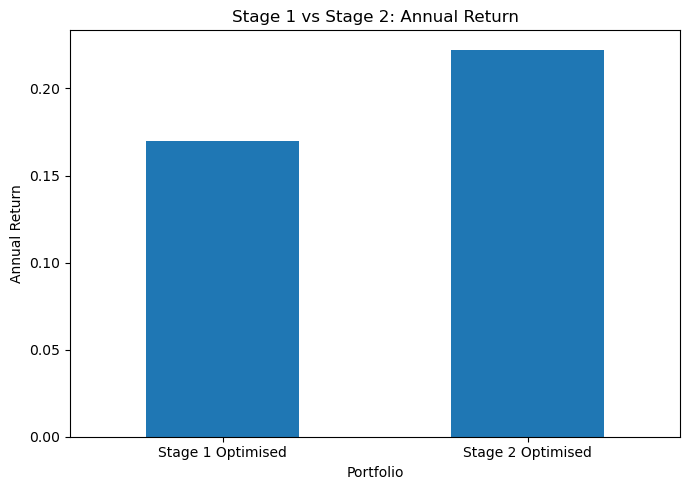

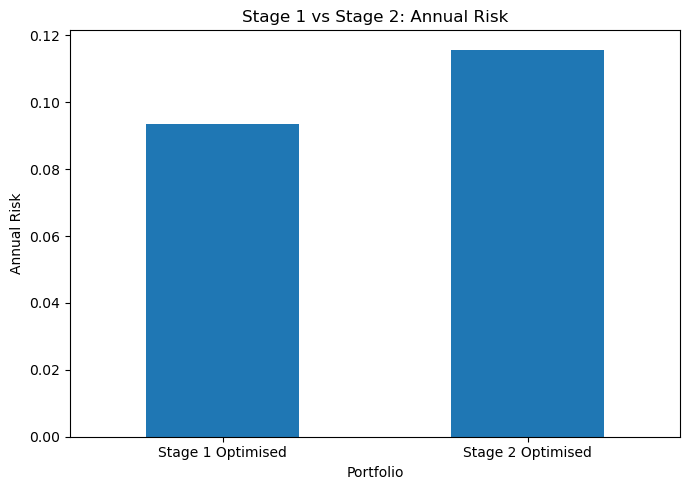

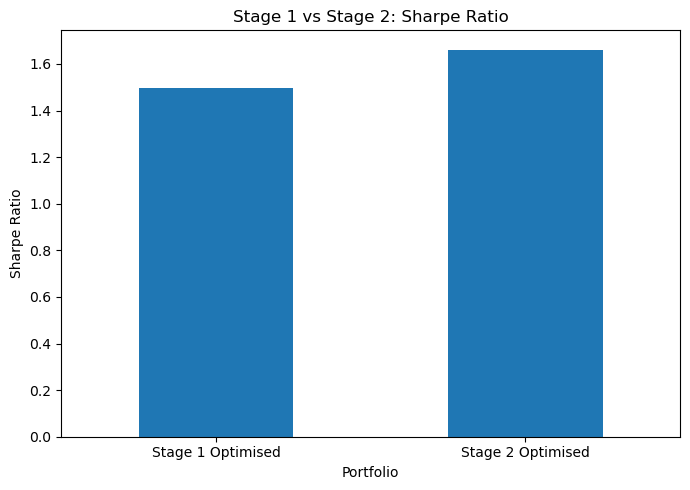

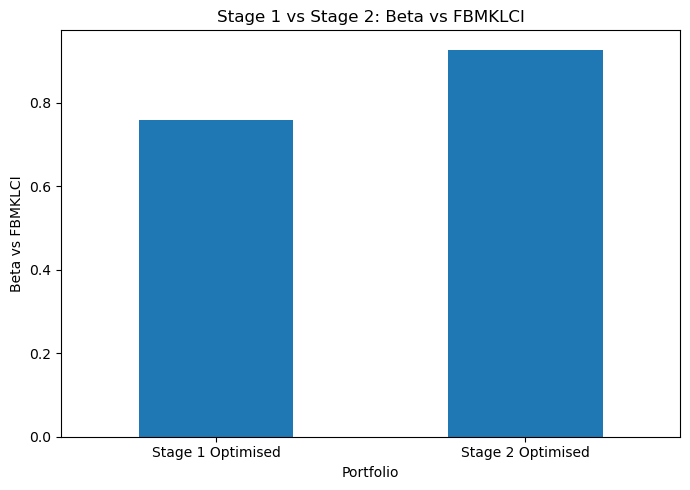

In [40]:
metrics_to_plot = ["Annual Return", "Annual Risk", "Sharpe Ratio", "Beta vs FBMKLCI"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    portfolio_comparison[metric].plot(kind="bar")
    plt.title(f"Stage 1 vs Stage 2: {metric}")
    plt.ylabel(metric)
    plt.xlabel("Portfolio")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"output/figures/{metric.replace(' ', '_').replace('/', '_')}_comparison.png", dpi=300)
    plt.show()

### Portfolio Metric Comparison Interpretation

wait

## 3. Optimised Weight Distribution

The weight distribution shows how the optimiser allocated capital across selected stocks.

This helps explain whether the high-volatility additions were actually used by the optimiser or rejected due to poor risk-return characteristics.

<Figure size 1400x600 with 0 Axes>

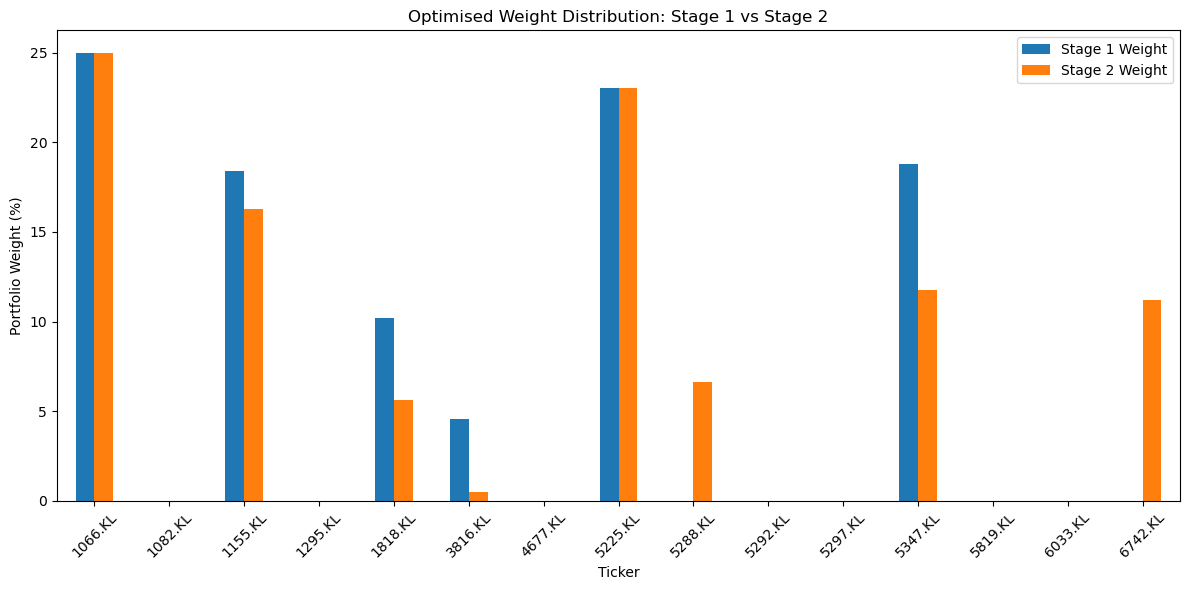

In [41]:
weight_percent = weight_comparison * 100

plt.figure(figsize=(14, 6))
weight_percent.plot(kind="bar", figsize=(12, 6))
plt.title("Optimised Weight Distribution: Stage 1 vs Stage 2")
plt.ylabel("Portfolio Weight (%)")
plt.xlabel("Ticker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/figures/weight_distribution_comparison.png", dpi=300)
plt.show()

### Weight Distribution Interpretation

wait

## 4. Individual Stock Risk-Return Scatter Plot

This plot compares selected stocks based on annual risk and annual return.

Stage 1 stocks should generally appear in the lower-risk region, while Stage 2 additions should appear in higher-risk areas.

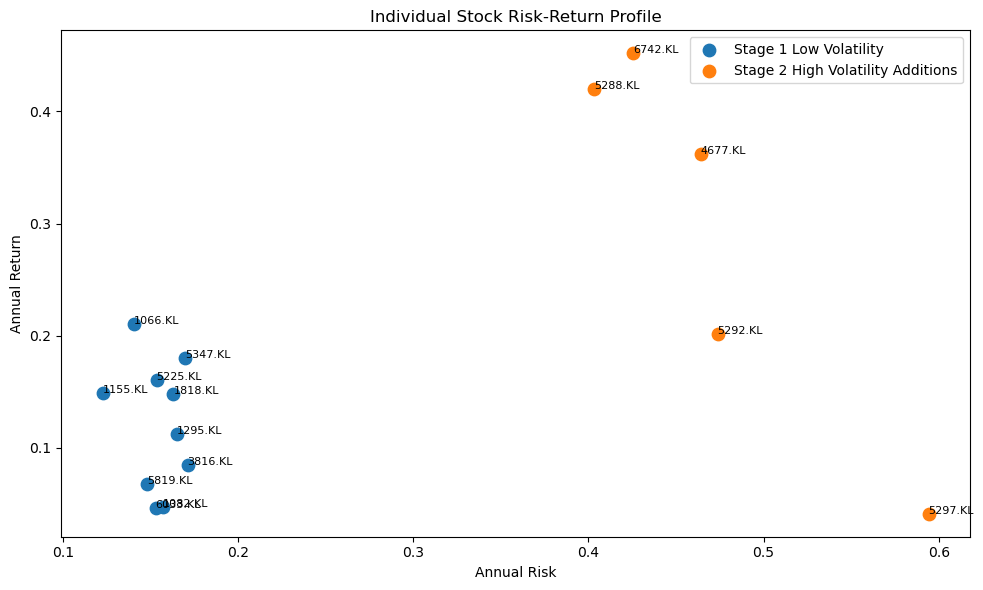

In [42]:
plt.figure(figsize=(10, 6))

stage1_data = individual_metrics[individual_metrics["Stage"] == "Stage 1 Low Volatility"]
stage2_data = individual_metrics[individual_metrics["Stage"] == "Stage 2 High Volatility Addition"]

plt.scatter(
    stage1_data["Annual Risk"],
    stage1_data["Annual Return"],
    label="Stage 1 Low Volatility",
    s=80
)

plt.scatter(
    stage2_data["Annual Risk"],
    stage2_data["Annual Return"],
    label="Stage 2 High Volatility Additions",
    s=80
)

for ticker, row in individual_metrics.iterrows():
    plt.text(row["Annual Risk"], row["Annual Return"], ticker, fontsize=8)

plt.title("Individual Stock Risk-Return Profile")
plt.xlabel("Annual Risk")
plt.ylabel("Annual Return")
plt.legend()
plt.tight_layout()
plt.savefig("output/figures/risk_return_scatter.png", dpi=300)
plt.show()

### Risk-Return Scatter Plot Interpretation

wait

## 5. Sharpe Ratio Comparison

Sharpe ratio measures risk-adjusted return. A higher Sharpe ratio indicates better return earned per unit of risk.

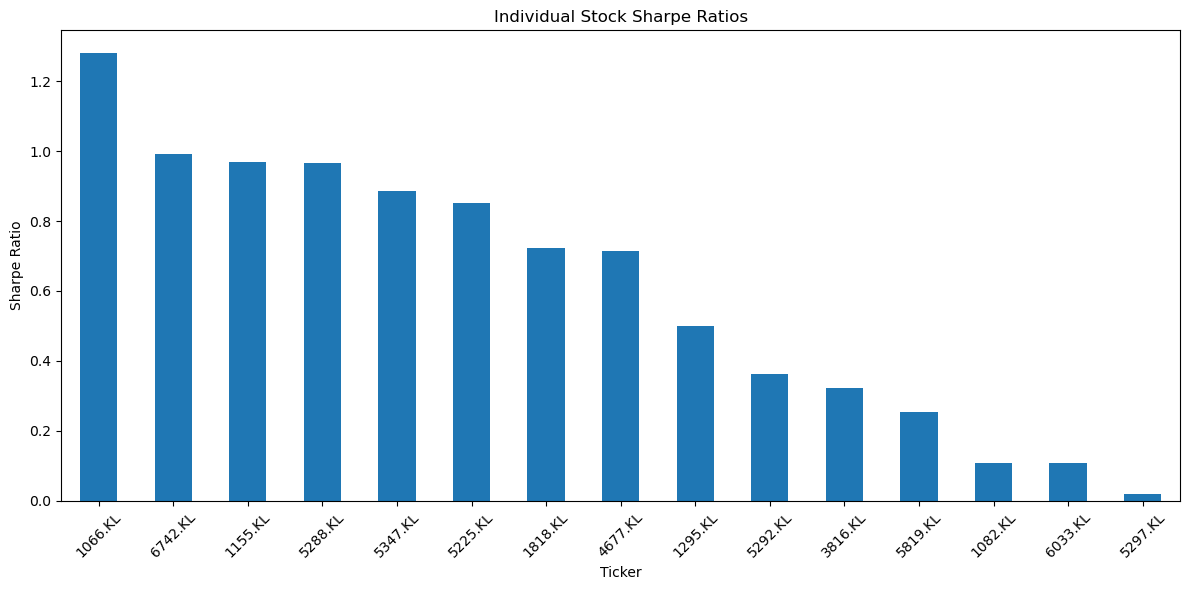

In [43]:
sharpe_sorted = individual_metrics["Sharpe Ratio"].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sharpe_sorted.plot(kind="bar")
plt.title("Individual Stock Sharpe Ratios")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Ticker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/figures/individual_sharpe_ratios.png", dpi=300)
plt.show()

### Sharpe Ratio Interpretation

wait

## 6. Correlation Heatmap

Correlation helps explain diversification. Higher correlation means stocks move more similarly, reducing diversification benefits.

The Stage 2 heatmap is especially useful because it shows whether high-volatility additions diversify the portfolio or simply add clustered risk.

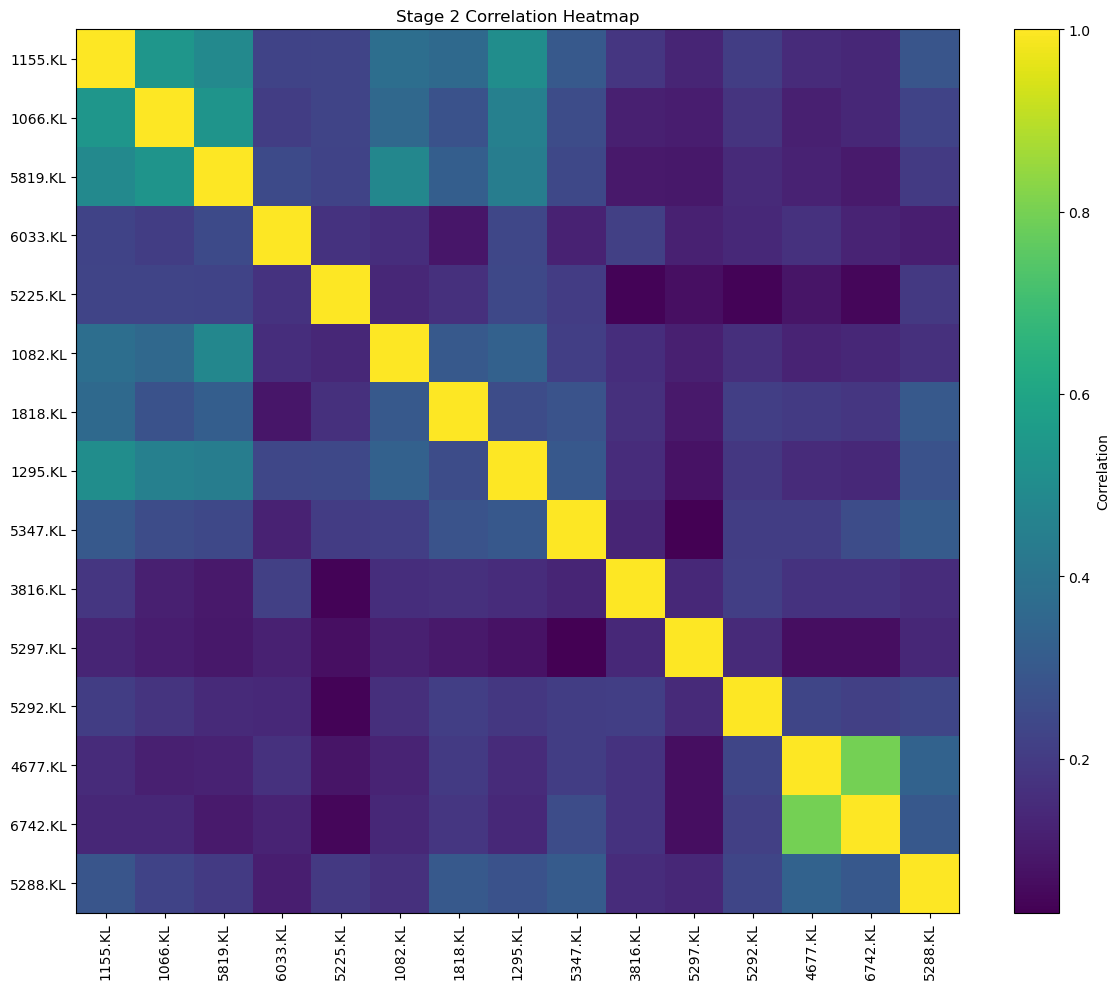

In [44]:
correlation_stage2 = pd.read_csv("output/correlation_stage2.csv", index_col=0)

plt.figure(figsize=(12, 10))
plt.imshow(correlation_stage2, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_stage2.columns)), correlation_stage2.columns, rotation=90)
plt.yticks(range(len(correlation_stage2.index)), correlation_stage2.index)
plt.title("Stage 2 Correlation Heatmap")
plt.tight_layout()
plt.savefig("output/figures/stage2_correlation_heatmap.png", dpi=300)
plt.show()

### Correlation Heatmap Interpretation

wait

### Overall Visual Summary

The visual results support the quantitative comparison between Stage 1 and Stage 2. Stage 1 is more defensive, with lower risk, lower beta, and allocation mainly to stable low-volatility stocks. Stage 2 achieves higher annual return and a slightly higher Sharpe ratio, but this comes with higher annual risk and higher beta.

The charts show that the Stage 2 improvement is mainly driven by 4677.KL, which is the only high-volatility addition receiving positive allocation. Most other high-volatility additions are rejected by the optimiser due to weak standalone performance, negative Sharpe ratios, or high correlation with similar stocks.

Therefore, Stage 2 provides better risk-adjusted performance, but Stage 1 remains the more conservative income portfolio.